# **Comparative Analysis of Literary Translations in the Odyssey: Zipf's Law in Depth**

This is a comparative Zipf's Law analysis of six translations spanning roughly the last century: 1919–2018. 

## **Road Map**

### I. Libraries, files, and paths

### II. Zipf's Law Analysis

1. All-in, straightforward model  
    a) TTR Computation  
    b) Shapiro-Wilk test to check for normality  
    c) One-wat ANOVA for overall differences  
    d) Pairwise t-test using Bonferroni coprrection  
    c) Meassuring effect size ussing Cohen's d  

2. Adaptive models  
    a) Mixed-Effects model: author fixed effect / book as random effect  
    b) Standardized TTR:   
    c) Moving-average TTR: translation as temporal change  

3. Supplement models  
    a) Lexical Density   
    b) Diachronic analysis  
    c) Semantic fields:  

### IV. Discussing Results
    

## **I. Libraries, files, and paths**

In [1]:
#### Other libraries
import sys
import os

import ast
from collections import Counter

import re
import nltk

In [2]:
#### Pandas set-up
import numpy as np
import pandas as pd

In [3]:
#### Visualization
sys.path.append('/Users/debr/English-Homer') 
import matplotlib.pyplot as plt
import seaborn as sns
import bard_visualization as viz # My Vizualization library

Bard viz is on the stage!


In [4]:
# Import my functions
sys.path.append('/Users/debr/English-Homer/functions') 
import e_nlp as e

e enters! »----> use e.<function>

e.g., for pipeline:
		 nlp = e.NLPPipeline(language="english")

Stopwords customized:
  Added: {'two', 'six', 'ten', 'eight', "'", 'three', "'and", 'five', 'n', 'seven', 'nine', 'one', 'four'}
  Removed: {''}
  Total stopwords: 211
Punctuation customized:
  Keeping: {'', '-'}
  Additional removals: {'\\', '‘', '’', '”', '…', '-', '—', '“'}
  Punctuation to be removed: !"#$%&'()*+,-./:;<=>?@[\]^_`{|}~—‘’“”…


[nltk_data] Downloading package punkt_tab to /Users/debr/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [5]:
#### Cell display options
pd.set_option("display.max_rows", 2000)  # Increase row display
pd.set_option("display.max_colwidth", 200)  # Prevent truncation of long values
pd.set_option("display.precision", 2)  # Display numbers with two decimal places
pd.set_option("display.float_format", "{:.2f}".format)  # Format float numbers
pd.set_option("display.max_columns", None)  # Show all columns
#pd.set_option("display.expand_frame_repr", False)  # Prevent wrapping in DataFrames
pd.set_option("display.width", 1000)  # Prevent wrapping in DataFrames
pd.set_option("colheader_justify", "left")

In [6]:
#### File management
# TO UPDATE
nb_id = "Etymology_Six_Modern"
translators = ["AT_Murray", "Fitzgerald", "Lattimore", "Fagles", "Wilson", "Green"]

# Paths
output_path = f"/Users/debr/English-Homer/{nb_id}/"
os.makedirs(os.path.dirname(output_path), exist_ok=True)

output_path_plots = f"{output_path}/{nb_id}_plots/"
os.makedirs(os.path.dirname(output_path_plots), exist_ok=True)

In [7]:
# Daframe with all the translators
dfs = []

for odyssey in translators:
    filepath = f"/Users/debr/odysseys_en/dataframed/Odyssey_{odyssey}_DataFrame.csv"
    temp_df = pd.read_csv(filepath)  
    dfs.append(temp_df)  # Append it to the list

df = pd.concat(dfs, axis=0, ignore_index=True)

df["text"] = df["text"].apply(ast.literal_eval)
df["tokens"] = df["tokens"].apply(ast.literal_eval)
df['translator'] = pd.Categorical(df['author'])
df["book_num"] = pd.Categorical(df["book_num"])
df = df[['translator', 'book_num', 'text', 'tokens']]
e.check_df(df)

Oh, yeah! No missing values here!

* df columns: Index(['translator', 'book_num', 'text', 'tokens'], dtype='object') 

* Shape: (144, 4) 

* Total memory: 3.488415


#### 2. **The translators**

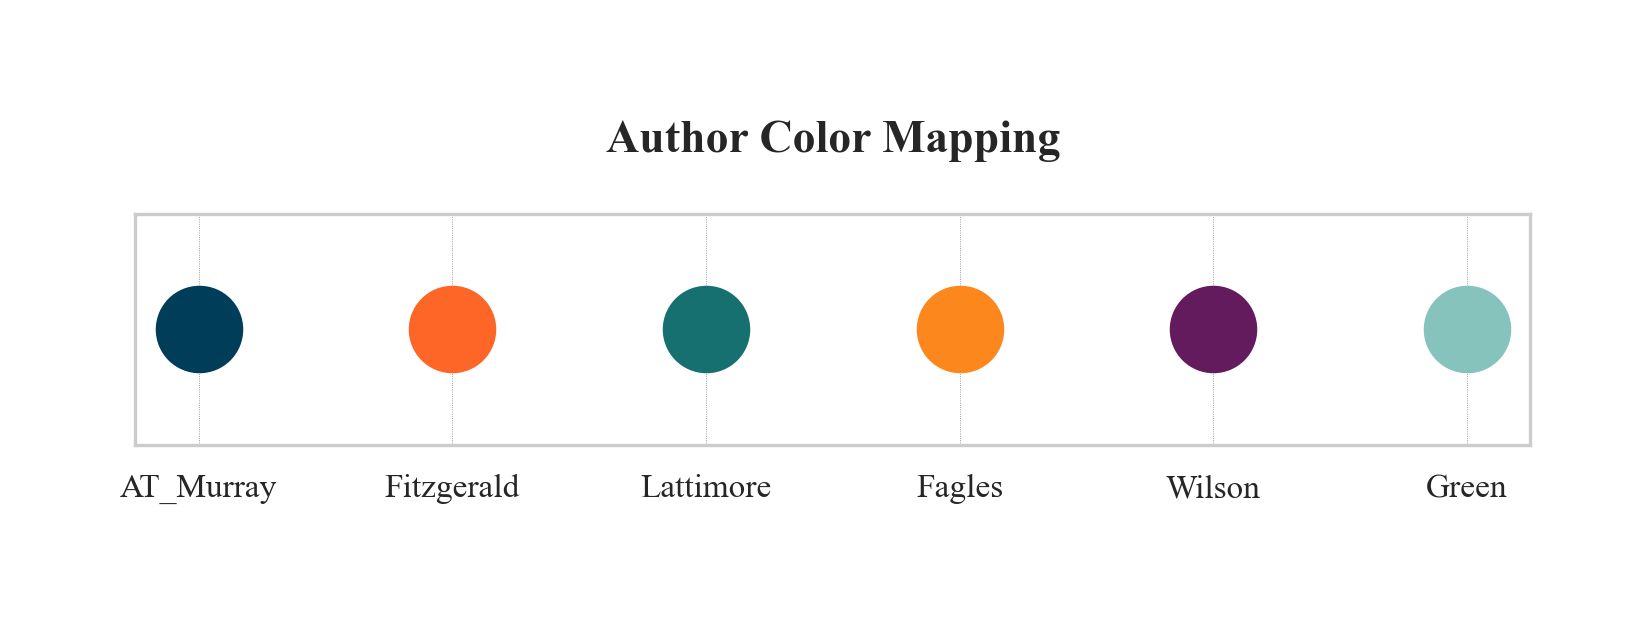

In [8]:
# Color mapping authors
palette = {author: color for author, 
           color in zip(translators, viz.color_palette.values())}

plt.figure(figsize=(6, 1))

for i, (author, color) in enumerate(palette.items()):
    plt.scatter(i, 0, color=color, s=400)

plt.xticks(range(len(palette)), palette.keys(), fontsize=8)
plt.yticks([])
plt.title("Author Color Mapping", fontsize=11)
plt.savefig(f"{output_path_plots}author_color_mapping-{nb_id}.png")
plt.show()

________________________________
## **II. Etymology percentage**

### **What and why:** 




### **Implications for Translation Studies**

**a) 

**b.1) 



### **Implementation** 




In [ ]:
# The dictionary of etymology





One-Way ANOVA (Single Test for All Translators)

The ANOVA test is used when you want to compare the means of more than two groups—in this case, the slopes of the different translators. This will tell you if there are any significant differences between the slopes across all translators.
